Last time we looked at *random search*, in particular we introduced the idea of keeping track of a *best hypothesis* and the corresponding *loss function* and using this to find increasingly good solutions to the problem. Random search is great because all we need is a way of generating candidate solutions and a way of evaluating them and we can make some progress on the problem, but it isn't the best we can do. 

One problem with random search is that we aren't getting any better at picking new solutions as we see which hypotheses are good or bad. Gradient descent is one way to fix that!

Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient Descent 

Recall that the definition of the derivative is $\frac{\delta f(x)}{\delta x} = lim_{\delta x\to0} \frac{f(x + \delta x) - f(x)}{\delta x}$ and that this tells us how steep the gradient of the tangent line is at x. Therefore, we can use the derivative to find low points in our function.

Suppose we have our loss function $L(x)$ and a current best guess for the solution $x^* = U_n$, then we can update our guess by subtracting something that looks like how steep the gradient is. Let us define our step $\Delta$ for some "learning rate" $\lambda$:

$\Delta (U_n) = - \lambda \cdot \frac{L(U_n + \delta x) - L(U_n)}{\delta x}$

for some suitably small $\delta x$ and $\lambda$

Then our next guess $U_{n+1}$ given our last guess was $U_n$ is simply:-

$U_{n + 1} = U_n + \Delta (U_n)$

### In Simpler Terms

That was a lot of maths, so let's express it in words instead. The steps are:

- Pick a loss function $L(x)$ and an initial guess $U_n$.
- Repeatedly find the derivative of $L(U_n)$ and subtract a constant $\lambda$ times the derivative from $U_n$ to update to our next guess.
- Eventually the process is done and we have our final answer $x^* = U_n$ (the final $U_n$).

Effectively, we are starting at a single point and then rolling downhill until we can't roll any lower.

### Polynomial Solver

Let's use our gradient descent method to find the roots for the equation $x^2 - 6x + 5 = 0$. By factorisation we can see that $f(x) = (x - 5)(x - 1)$ so we expect the solutions to be $x = 1$ and $x = 5$.

Notice that gradient descent finds the lowest value but we want the value for which $f(x) = 0$, so by defining $L(x) = f(x)^2$ we can ensure that gradient descent finds the root rather than the minima for $f(x)$.

In [1]:
def polynomial(x):
    return(x**2 - 6*x + 5)

def loss(x):
    return(polynomial(x) ** 2)

def delta_step(x, dx = 0.00001, learning_rate = 0.01):
    return(- learning_rate * (loss(x+dx) - loss(x)) / dx)

hypothesis = 0
for i in range(1000):
    hypothesis = hypothesis + delta_step(hypothesis)
print(f"Gradient descent yields f(x) = 0 at x = {hypothesis:.2f}")

Gradient descent yields f(x) = 0 at x = 1.00


So we correctly found one of the rotos for $f(x) = 0$ for this function. We found the value closest to our initial hypothesis, because we effectively "rolled" down the gradient of the loss function until we found a loss of 0. To see what's going on, let's plot out loss function, our $f(x)$, and our solution.

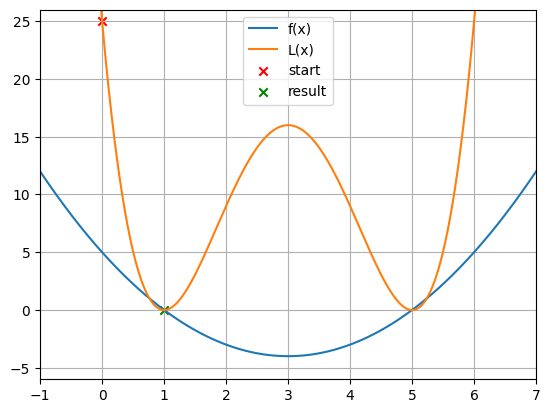

In [2]:
x_data = np.linspace(-1, 7, 1000)
poly_data = [polynomial(x) for x in x_data]
loss_data = [loss(x) for x in x_data]
plt.plot(x_data, poly_data, label = "f(x)")
plt.plot(x_data, loss_data, label = "L(x)")
plt.scatter(0, loss(0), label = "start", marker = "x", color = "red")
plt.scatter(hypothesis, loss(hypothesis), label = "result", marker = "x", color = "green")
plt.ylim(-6, 26)
plt.xlim(-1, 7)
plt.legend()
plt.grid(True)
plt.show()

### What can go wrong?

So gradient descent managed to find our root for $f(x) = 0$, but something can go wrong. Try to predict when gradient descent might not do so well! Recall that it effectively treats the loss function as a hill and rolls down to the nearest low point.

To illustrate the problem, let's try to find the lowest point (note, not the root!) for $f(x) = x cos(x)$ in the range $x \in (- \pi, \pi)$.

In [3]:
def function(x):
    return(x * np.cos(x))

def loss(x):
    return(function(x))

def delta_step(x, dx = 0.00001, learning_rate = 0.01):
    return(- learning_rate * (loss(x+dx) - loss(x)) / dx)

hypothesis = 0
for i in range(1000):
    hypothesis = hypothesis + delta_step(hypothesis)
print(f"Gradient descent yields f(x) = 0 at x = {hypothesis:.2f}")

Gradient descent yields f(x) = 0 at x = -0.86


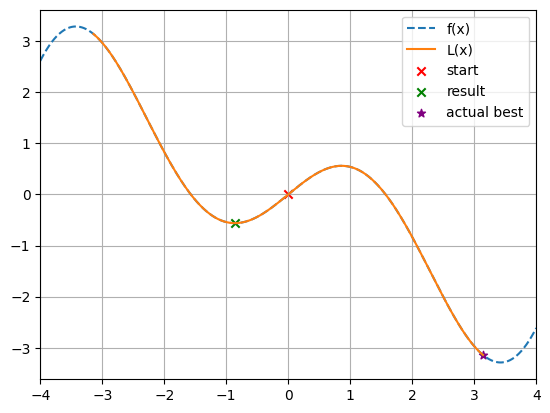

In [4]:
x_data = np.linspace(-4, 4, 1000)
domain = np.linspace(-np.pi, np.pi, 1000)
trig_data = [function(x) for x in x_data]
loss_data = [loss(x) for x in domain]
plt.plot(x_data, trig_data, "--", label = "f(x)")
plt.plot(domain, loss_data, label = "L(x)")
plt.scatter(0, loss(0), label = "start", marker = "x", color = "red")
plt.scatter(hypothesis, loss(hypothesis), label = "result", marker = "x", color = "green")
plt.scatter(np.pi, loss(np.pi), label = "actual best", marker = "*", color = "purple")
plt.xlim(-4, 4)
plt.legend()
plt.grid(True)
plt.show()

So the problem here was that gradient descent got stuck in a *local optimum*. What this means is, it rolled down the hill to the low point on that side, but there was an even better *global optimum* it could have got to on the other side of the hill! Let's try again only with $x = 2$ as our start so this doesn't happen. Will something still go wrong?

In real applications of gradient descent we would repeatedly pick random starting points and train to convergence so if we get stuck in a local optimum we simply start a new *epoch* and hopefully find a solution which is globally optimal, but here it's simpler to just set $x = 2$.

Gradient descent yields f(x) = 0 at x = 3.43


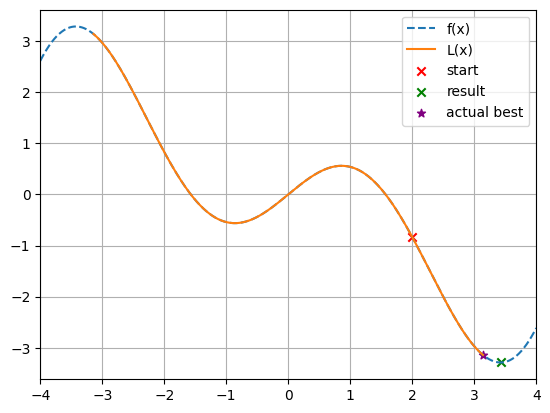

In [5]:
hypothesis = 2
for i in range(1000):
    hypothesis = hypothesis + delta_step(hypothesis)
print(f"Gradient descent yields f(x) = 0 at x = {hypothesis:.2f}")
x_data = np.linspace(-4, 4, 1000)
domain = np.linspace(-np.pi, np.pi, 1000)
trig_data = [function(x) for x in x_data]
loss_data = [loss(x) for x in domain]
plt.plot(x_data, trig_data, "--", label = "f(x)")
plt.plot(domain, loss_data, label = "L(x)")
plt.scatter(2, loss(2), label = "start", marker = "x", color = "red")
plt.scatter(hypothesis, loss(hypothesis), label = "result", marker = "x", color = "green")
plt.scatter(np.pi, loss(np.pi), label = "actual best", marker = "*", color = "purple")
plt.xlim(-4, 4)
plt.legend()
plt.grid(True)
plt.show()

3.43 is bigger than $\pi$ so our solution is not in the *feasible space*. The easiest solution here is to create a *penalty loss* $L_P(x)$ which acts like $L(x)$ for feasible $x$ but deters gradient descent from picking values outside of $x \in (-\pi, \pi)$

Gradient descent with penalty losses yields f(x) = 0 at x = 3.1372805403


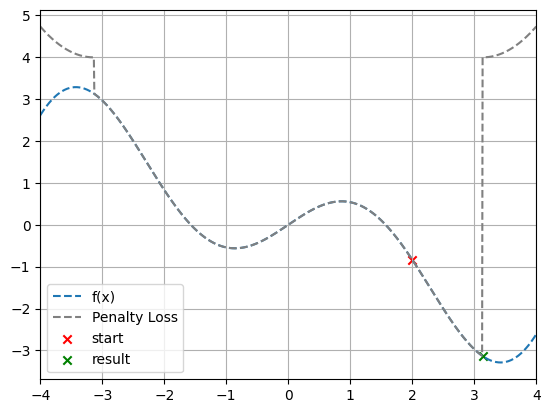

In [9]:
def function(x):
    return(x * np.cos(x))

def loss(x):
    return(function(x))

def is_valid(x):
    #Make values very close to pi invalid so we can't overshoot
    if np.fabs(x) < np.pi - 0.01:
        return(True)
    else:
        return(False)

def penalty_loss(x):
    if is_valid(x):
        return(loss(x))
    else:
        return(4 + (np.fabs(x) - np.pi) ** 2)

def delta_step(x, dx = 0.00001, learning_rate = 0.001):
    return(- learning_rate * (penalty_loss(x + dx) - penalty_loss(x)) / dx)

hypothesis = 2
for i in range(1000):
    hypothesis = hypothesis + delta_step(hypothesis)
print(f"Gradient descent with penalty losses yields f(x) = 0 at x = {hypothesis:.10f}")

x_data = np.linspace(-4, 4, 1000)
domain = np.linspace(-np.pi, np.pi, 1000)
trig_data = [function(x) for x in x_data]
loss_data = [loss(x) for x in domain]
penalty_data = [penalty_loss(x) for x in x_data]
plt.plot(x_data, trig_data, "--", label = "f(x)")
plt.plot(x_data, penalty_data, "--", color = "gray", label = "Penalty Loss")
plt.scatter(2, loss(2), label = "start", marker = "x", color = "red")
plt.scatter(hypothesis, loss(hypothesis), label = "result", marker = "x", color = "green")
plt.xlim(-4, 4)
plt.legend()
plt.grid(True)
plt.show()

Some important facts about our penalty loss:

- It is not extremely high. If $L_p(x) >> L(x)$ then the gradient explodes and $x$ drifts unpredictably.

- It strictly increases as we get deeper into the infeasible space: the last thing we want is gradient descent getting stuck in a local optimum in the infeasible space because the penalty was either flat or contained a local optimum.

- Every infeasible point in $L_p(x)$ is worse than every feasible point. If this does not hold, we can still choose infeasible values.

- We label points which are technically valid but on the border of validity as invalid to ensure gradient descent can't overshoot them and enter the infeasible space.

# Task - Extend Gradient Descent to multiple dimensions

All the examples so far have had a 1-dimensinal $x$, it's time to extend this. 

Before we had $\Delta (U_n) = - \lambda \cdot \frac{L(U_n + \delta x) - L(U_n)}{\delta x}$, so let's now make $x$ and $\Delta (U_n)$ vectors such that the $i^{th}$ element in $\Delta (U_n)$ is given by:

$\Delta (U_n)_i = - \lambda \cdot \frac{L(U_m) - L(U_n)}{\delta x}$ where $U_{mj} =
\begin{cases}
U_{nj}, & j \ne i \\
U_{ni} + \delta x, & j = i
\end{cases}$

In words, we're finding a vector of gradients in 